# Uplift Modeling: Core Models

This notebook keeps only the top-performing configurations for:
S-Learner, T-Learner, Class Transformation, X-Learner, R-Learner.
Structure and metrics follow `modeling.ipynb` (plots + uplift metrics).


In [16]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import cross_val_predict, KFold
from sklearn.linear_model import LinearRegression


In [17]:
def asd_score(y_true, uplift_pred, treatment, n_bins=10):
    df = pd.DataFrame({
        "y": np.asarray(y_true),
        "uplift": np.asarray(uplift_pred),
        "treatment": np.asarray(treatment),
    })
    df["decile"] = pd.qcut(
        df["uplift"].rank(method="first"),
        q=n_bins,
        labels=False,
        duplicates="drop",
    )
    sq = []
    for _, grp in df.groupby("decile"):
        trt = grp[grp["treatment"] == 1]["y"]
        ctrl = grp[grp["treatment"] == 0]["y"]
        if len(trt) == 0 or len(ctrl) == 0:
            continue
        sq.append((trt.mean() - ctrl.mean() - grp["uplift"].mean()) ** 2)
    return float(np.mean(sq)) if sq else np.nan

def decile_stats(pred, y, t, n_bins=10):
    df = pd.DataFrame({"pred": np.asarray(pred), "y": np.asarray(y), "t": np.asarray(t)})
    df["bin"] = pd.qcut(
        df["pred"].rank(method="first"),
        q=n_bins,
        labels=False,
        duplicates="drop",
    )
    rows = []
    for b in sorted(df["bin"].unique()):
        g = df[df["bin"] == b]
        cr_t = g.loc[g["t"] == 1, "y"].mean()
        cr_c = g.loc[g["t"] == 0, "y"].mean()
        rows.append({"Decile": int(b) + 1, "CR_T": cr_t, "CR_C": cr_c, "Uplift": cr_t - cr_c})
    return pd.DataFrame(rows)


In [18]:
import sklearn.utils
from sklearn.utils._plotting import check_matplotlib_support
sklearn.utils.check_matplotlib_support = check_matplotlib_support

from sklift.models import SoloModel, TwoModels, ClassTransformation
from sklift.metrics import (
    qini_auc_score,
    uplift_auc_score,
    uplift_at_k,
    weighted_average_uplift,
    qini_curve,
    uplift_curve,
)


In [19]:
X_train = pd.read_csv("data/processed/X_train.csv")
X_test = pd.read_csv("data/processed/X_test.csv")
y_train = pd.read_csv("data/processed/y_train.csv").squeeze()
y_test = pd.read_csv("data/processed/y_test.csv").squeeze()
treatment_train = pd.read_csv("data/processed/treatment_train.csv").squeeze()
treatment_test = pd.read_csv("data/processed/treatment_test.csv").squeeze()

treatment_train = (treatment_train == "test").astype(int)
treatment_test = (treatment_test == "test").astype(int)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Treatment rate: train={treatment_train.mean():.4f}, test={treatment_test.mean():.4f}")


Train: (480920, 244), Test: (206109, 244)
Treatment rate: train=0.7509, test=0.7509


In [20]:
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier, LGBMRegressor
from causalml.inference.meta import BaseXRegressor, BaseRRegressor

cat_params = dict(
    iterations=200,
    depth=6,
    learning_rate=0.1,
    random_state=42,
    silent=True,
)

lgbm_ct_params = dict(
    n_estimators=500,
    max_depth=6,
    num_leaves=31,
    learning_rate=0.05,
    random_state=42,
    verbose=-1,
    n_jobs=-1,
)

lgbm_meta_params = dict(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    random_state=42,
    verbose=-1,
    n_jobs=-1,
)

predictions = {}
predictions_train = {}
models = {}


In [21]:
sm = SoloModel(
    estimator=CatBoostClassifier(**cat_params),
    method="treatment_interaction",
)
sm.fit(X_train, y_train, treatment_train)
predictions["S-Learner (interaction)"] = sm.predict(X_test)
predictions_train["S-Learner (interaction)"] = sm.predict(X_train)
models["S-Learner (interaction)"] = sm
print("S-Learner (interaction) done")

tm = TwoModels(
    estimator_trmnt=CatBoostClassifier(**cat_params),
    estimator_ctrl=CatBoostClassifier(**cat_params),
    method="ddr_control",
)
tm.fit(X_train, y_train, treatment_train)
predictions["T-Learner (DDR)"] = tm.predict(X_test)
predictions_train["T-Learner (DDR)"] = tm.predict(X_train)
models["T-Learner (DDR)"] = tm
print("T-Learner (DDR) done")


S-Learner (interaction) done
T-Learner (DDR) done


In [22]:
ct_base = ClassTransformation(estimator=LGBMClassifier(**lgbm_ct_params))
ct_base.fit(X_train, y_train, treatment_train)
ct_test = ct_base.predict(X_test)
models["CT base (LGBM)"] = ct_base
print("CT base done")


CT base done


In [23]:
X_tr = X_train.values
X_te = X_test.values
y_tr = y_train.values.astype(float)
t_tr = treatment_train.values.astype(int)

prop_model = LGBMClassifier(**lgbm_meta_params)
p_train = cross_val_predict(prop_model, X_tr, t_tr, cv=3, method="predict_proba")[:, 1]
prop_model.fit(X_tr, t_tr)
p_test = prop_model.predict_proba(X_te)[:, 1]
p_train_full = prop_model.predict_proba(X_tr)[:, 1]
p_train = np.clip(p_train, 0.01, 0.99)
p_test = np.clip(p_test, 0.01, 0.99)
p_train_full = np.clip(p_train_full, 0.01, 0.99)


In [24]:
kf = KFold(n_splits=3, shuffle=True, random_state=42)
ct_oof = np.zeros(len(X_train))
for tr_idx, val_idx in kf.split(X_tr):
    ct_fold = ClassTransformation(estimator=LGBMClassifier(**lgbm_ct_params))
    ct_fold.fit(X_train.iloc[tr_idx], y_train.iloc[tr_idx], treatment_train.iloc[tr_idx])
    ct_oof[val_idx] = ct_fold.predict(X_train.iloc[val_idx])

pseudo = t_tr * y_tr / p_train - (1 - t_tr) * y_tr / (1 - p_train)
lr = LinearRegression()
lr.fit(ct_oof.reshape(-1, 1), pseudo)
ct_lin_train = lr.predict(ct_oof.reshape(-1, 1))
ct_lin_test = lr.predict(ct_test.reshape(-1, 1))
predictions["CT + Linear (OLS)"] = ct_lin_test
predictions_train["CT + Linear (OLS)"] = ct_lin_train
print("CT + Linear (OLS) done")


CT + Linear (OLS) done


In [25]:
xl = BaseXRegressor(learner=LGBMRegressor(**lgbm_meta_params))
xl.fit(X=X_tr, treatment=t_tr, y=y_tr, p=p_train)
xl_pred = xl.predict(X=X_te, p=p_test).flatten()
xl_pred_train = xl.predict(X=X_tr, p=p_train_full).flatten()
predictions["X-Learner (LGBM)"] = xl_pred
predictions_train["X-Learner (LGBM)"] = xl_pred_train

rl = BaseRRegressor(learner=LGBMRegressor(**lgbm_meta_params))
rl.fit(X=X_tr, treatment=t_tr, y=y_tr, p=p_train)
rl_pred = rl.predict(X=X_te).flatten()
rl_pred_train = rl.predict(X=X_tr).flatten()
predictions["R-Learner (LGBM)"] = rl_pred
predictions_train["R-Learner (LGBM)"] = rl_pred_train

print("X-Learner and R-Learner done")


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/skle

X-Learner and R-Learner done


In [26]:
def evaluate_metrics(y, pred, t):
    return {
        "uplift@10%": uplift_at_k(y, pred, t, strategy="by_group", k=0.1),
        "uplift@30%": uplift_at_k(y, pred, t, strategy="by_group", k=0.3),
        "Qini AUC": qini_auc_score(y, pred, t),
        "Uplift AUC": uplift_auc_score(y, pred, t),
        "WAU": weighted_average_uplift(y, pred, t, strategy="by_group", bins=10),
        "ASD": asd_score(y, pred, t),
    }

results_test = []
results_train = []
for name, pred in predictions.items():
    row_t = {"Model": name}
    row_t.update(evaluate_metrics(y_test, pred, treatment_test))
    results_test.append(row_t)

    row_tr = {"Model": name}
    row_tr.update(evaluate_metrics(y_train, predictions_train[name], treatment_train))
    results_train.append(row_tr)

metrics_df_test = (
    pd.DataFrame(results_test)
    .set_index("Model")
    .sort_values("Qini AUC", ascending=False)
)

metrics_df_train = (
    pd.DataFrame(results_train)
    .set_index("Model")
    .sort_values("Qini AUC", ascending=False)
)

display(metrics_df_test)
display(metrics_df_train)


,uplift@10%,uplift@30%,Qini AUC,Uplift AUC,WAU,ASD
Model,,,,,,
CT + Linear (OLS),0.178985,0.032686,0.075240,0.045669,0.007558,0.002229
S-Learner (interaction),0.026860,0.015864,0.014839,0.008129,0.007561,0.000042
T-Learner (DDR),0.022388,0.014804,0.014404,0.007889,0.007561,0.000217
R-Learner (LGBM),0.020448,0.014683,0.010286,0.005684,0.007561,0.000182
X-Learner (LGBM),0.014142,0.010012,-0.001339,-0.000743,0.007561,0.000176


,uplift@10%,uplift@30%,Qini AUC,Uplift AUC,WAU,ASD
Model,,,,,,
R-Learner (LGBM),0.219798,0.095810,0.231136,0.127147,0.007542,0.006515
T-Learner (DDR),0.217888,0.095189,0.229725,0.126269,0.007542,0.005962
X-Learner (LGBM),0.177693,0.082626,0.195069,0.107002,0.007542,0.004814
S-Learner (interaction),0.121892,0.050319,0.108033,0.059292,0.007543,0.001353
CT + Linear (OLS),0.171623,0.031899,0.073277,0.044619,0.007544,0.002197


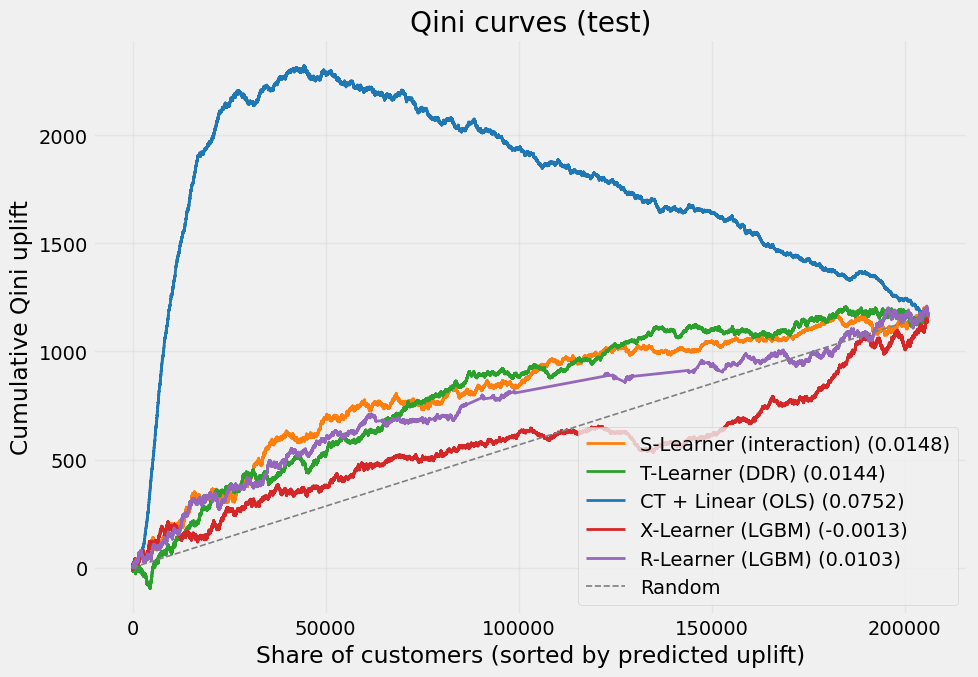

In [27]:
colors = {
    "S-Learner (interaction)": "#ff7f0e",
    "T-Learner (DDR)": "#2ca02c",
    "CT + Linear (OLS)": "#1f77b4",
    "X-Learner (LGBM)": "#d62728",
    "R-Learner (LGBM)": "#9467bd",
}

fig, ax = plt.subplots(figsize=(10, 7))
last_x = None
last_y = None
for name, pred in predictions.items():
    x_vals, y_vals = qini_curve(y_test, pred, treatment_test)
    last_x, last_y = x_vals, y_vals
    auc = qini_auc_score(y_test, pred, treatment_test)
    ax.plot(x_vals, y_vals, color=colors.get(name), linewidth=2, label=f"{name} ({auc:.4f})")
if last_x is not None:
    ax.plot([0, last_x[-1]], [0, last_y[-1]], color="gray", linestyle="--", linewidth=1.2, label="Random")
ax.set_title("Qini curves (test)")
ax.set_xlabel("Share of customers (sorted by predicted uplift)")
ax.set_ylabel("Cumulative Qini uplift")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()


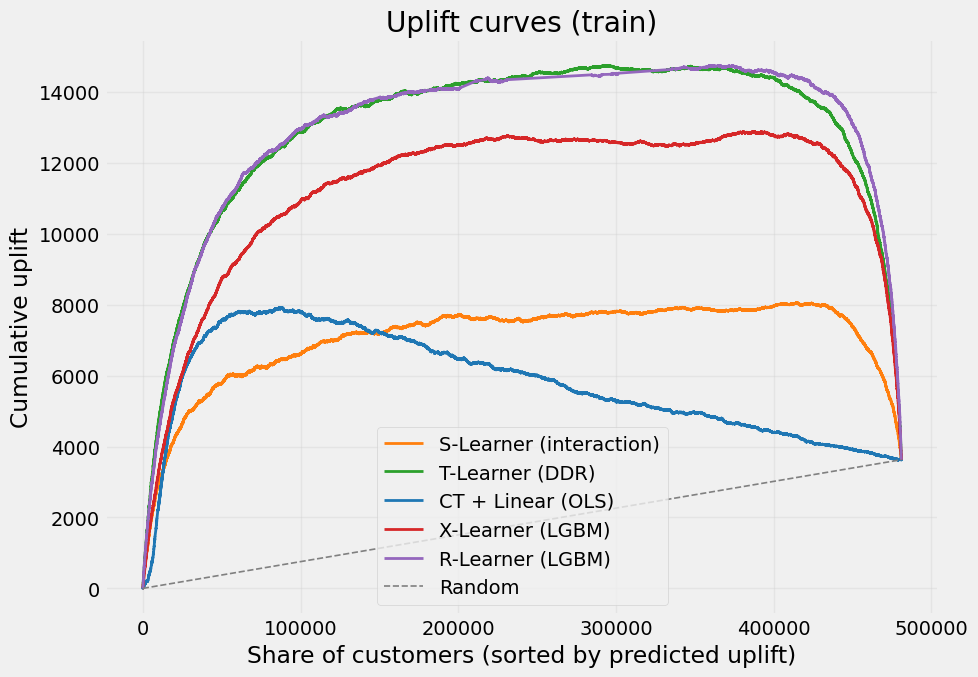

In [28]:
fig, ax = plt.subplots(figsize=(10, 7))
last_x = None
last_y = None
for name, pred in predictions_train.items():
    x_vals, y_vals = uplift_curve(y_train, pred, treatment_train)
    last_x, last_y = x_vals, y_vals
    ax.plot(x_vals, y_vals, color=colors.get(name), linewidth=2, label=name)
if last_x is not None:
    ax.plot([0, last_x[-1]], [0, last_y[-1]], color="gray", linestyle="--", linewidth=1.2, label="Random")
ax.set_title("Uplift curves (train)")
ax.set_xlabel("Share of customers (sorted by predicted uplift)")
ax.set_ylabel("Cumulative uplift")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()


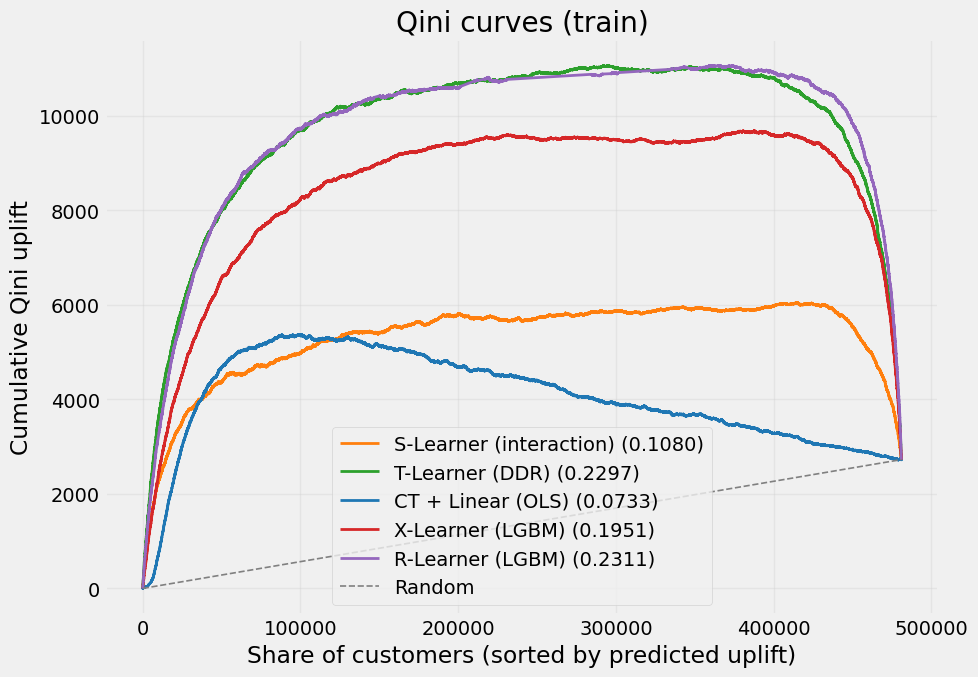

In [29]:
fig, ax = plt.subplots(figsize=(10, 7))
last_x = None
last_y = None
for name, pred in predictions_train.items():
    x_vals, y_vals = qini_curve(y_train, pred, treatment_train)
    last_x, last_y = x_vals, y_vals
    auc = qini_auc_score(y_train, pred, treatment_train)
    ax.plot(x_vals, y_vals, color=colors.get(name), linewidth=2, label=f"{name} ({auc:.4f})")
if last_x is not None:
    ax.plot([0, last_x[-1]], [0, last_y[-1]], color="gray", linestyle="--", linewidth=1.2, label="Random")
ax.set_title("Qini curves (train)")
ax.set_xlabel("Share of customers (sorted by predicted uplift)")
ax.set_ylabel("Cumulative Qini uplift")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()


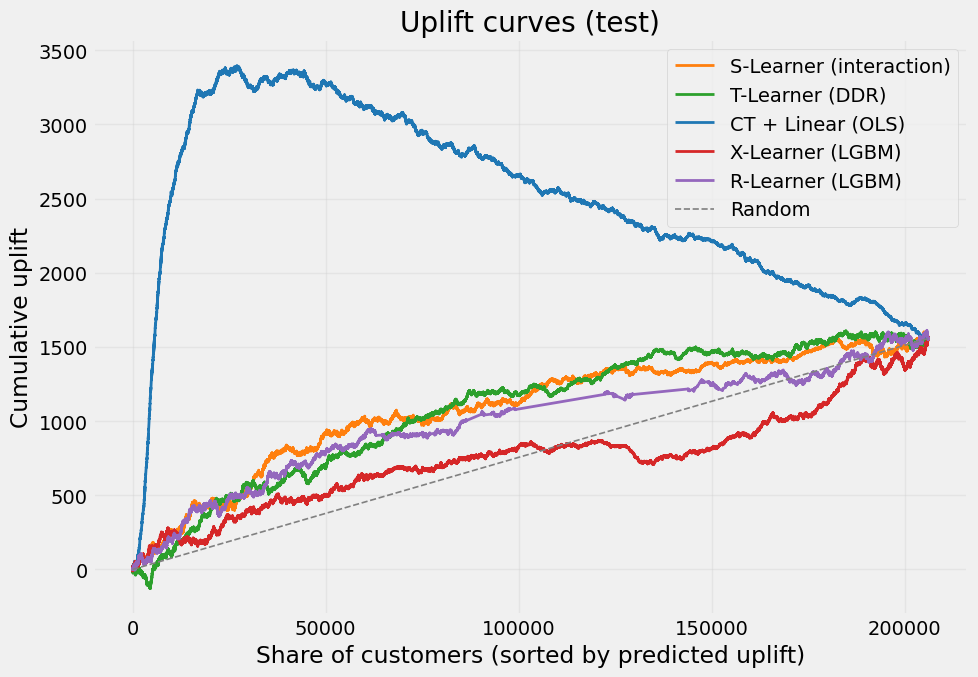

In [30]:
fig, ax = plt.subplots(figsize=(10, 7))
last_x = None
last_y = None
for name, pred in predictions.items():
    x_vals, y_vals = uplift_curve(y_test, pred, treatment_test)
    last_x, last_y = x_vals, y_vals
    ax.plot(x_vals, y_vals, color=colors.get(name), linewidth=2, label=name)
if last_x is not None:
    ax.plot([0, last_x[-1]], [0, last_y[-1]], color="gray", linestyle="--", linewidth=1.2, label="Random")
ax.set_title("Uplift curves (test)")
ax.set_xlabel("Share of customers (sorted by predicted uplift)")
ax.set_ylabel("Cumulative uplift")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()


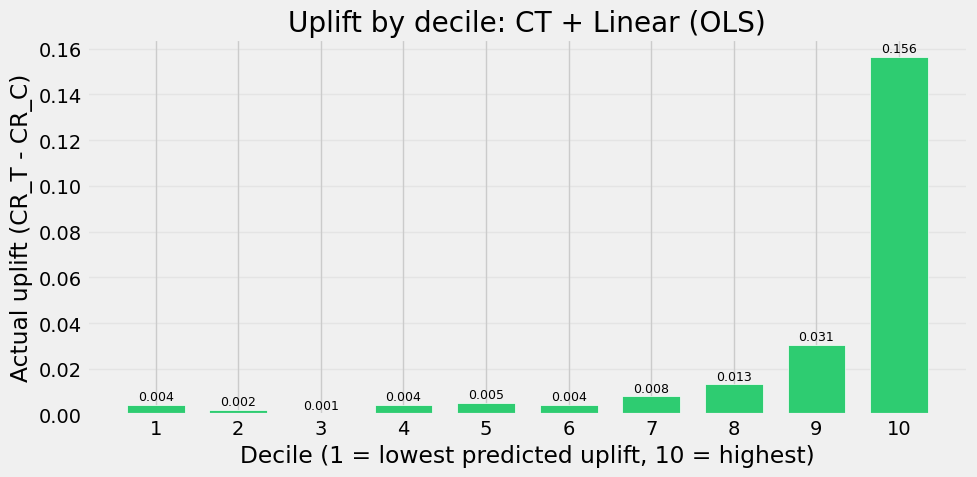

In [31]:
best_name = metrics_df_test.index[0]
best_pred = predictions[best_name]
bdf = decile_stats(best_pred, y_test, treatment_test, n_bins=10)

fig, ax = plt.subplots(figsize=(10, 5))
bar_colors = ["#2ecc71" if u > 0 else "#e74c3c" for u in bdf["Uplift"]]
ax.bar(bdf["Decile"], bdf["Uplift"], color=bar_colors, edgecolor="white", width=0.7)
ax.axhline(y=0, color="black", linewidth=0.8)
for _, row in bdf.iterrows():
    offset = 0.0008 if row["Uplift"] >= 0 else -0.0020
    ax.text(row["Decile"], row["Uplift"] + offset, f"{row['Uplift']:.3f}", ha="center", va="bottom", fontsize=9)
ax.set_xlabel("Decile (1 = lowest predicted uplift, 10 = highest)")
ax.set_ylabel("Actual uplift (CR_T - CR_C)")
ax.set_title(f"Uplift by decile: {best_name}")
ax.set_xticks(bdf["Decile"])
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()


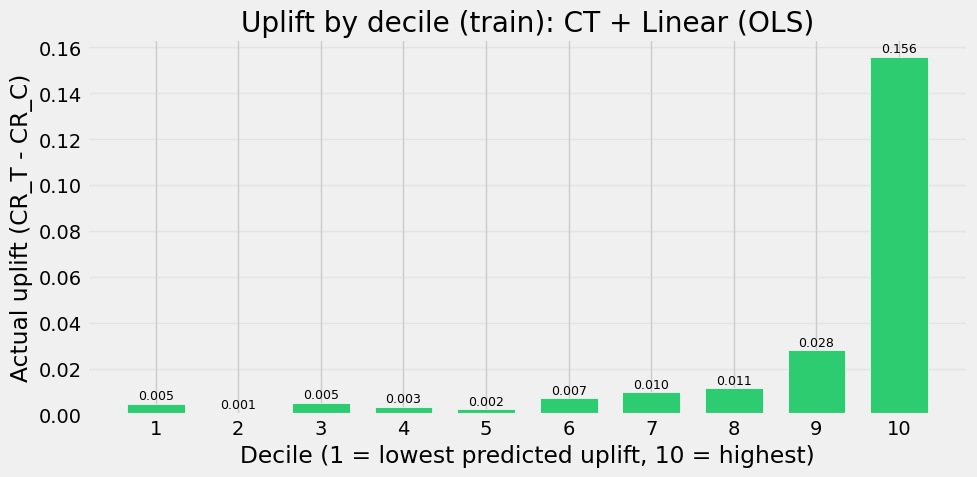

In [32]:
best_pred_train = predictions_train[best_name]
bdf_tr = decile_stats(best_pred_train, y_train, treatment_train, n_bins=10)

fig, ax = plt.subplots(figsize=(10, 5))
bar_colors = ["#2ecc71" if u > 0 else "#e74c3c" for u in bdf_tr["Uplift"]]
ax.bar(bdf_tr["Decile"], bdf_tr["Uplift"], color=bar_colors, edgecolor="white", width=0.7)
ax.axhline(y=0, color="black", linewidth=0.8)
for _, row in bdf_tr.iterrows():
    offset = 0.0008 if row["Uplift"] >= 0 else -0.0020
    ax.text(row["Decile"], row["Uplift"] + offset, f"{row['Uplift']:.3f}", ha="center", va="bottom", fontsize=9)
ax.set_xlabel("Decile (1 = lowest predicted uplift, 10 = highest)")
ax.set_ylabel("Actual uplift (CR_T - CR_C)")
ax.set_title(f"Uplift by decile (train): {best_name}")
ax.set_xticks(bdf_tr["Decile"])
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()


Mean: 0.0063, Std: 0.0011
Min: 0.0045, Max: 0.0130
% positive uplift: 100.0%


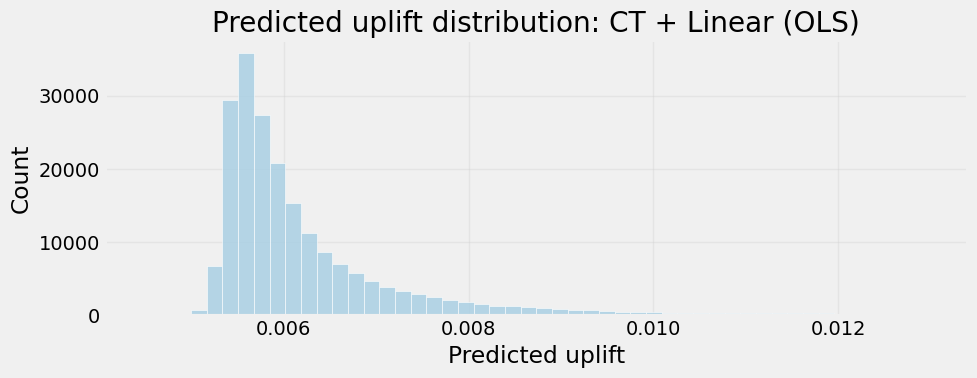

In [33]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(best_pred, bins=50, edgecolor="white", alpha=0.8)
ax.set_title(f"Predicted uplift distribution: {best_name}")
ax.set_xlabel("Predicted uplift")
ax.set_ylabel("Count")
ax.grid(True, alpha=0.3)
plt.tight_layout()

print(f"Mean: {best_pred.mean():.4f}, Std: {best_pred.std():.4f}")
print(f"Min: {best_pred.min():.4f}, Max: {best_pred.max():.4f}")
print(f"% positive uplift: {(best_pred > 0).mean():.1%}")


Mean: 0.0063, Std: 0.0012
Min: 0.0044, Max: 0.0139
% positive uplift: 100.0%


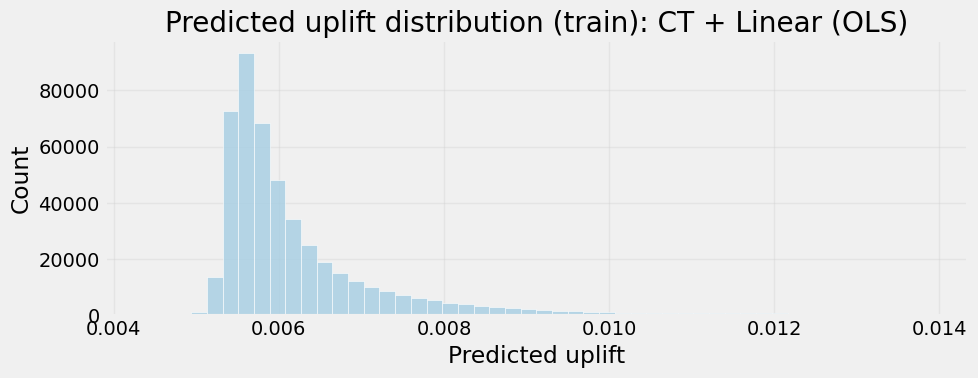

In [34]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(best_pred_train, bins=50, edgecolor="white", alpha=0.8)
ax.set_title(f"Predicted uplift distribution (train): {best_name}")
ax.set_xlabel("Predicted uplift")
ax.set_ylabel("Count")
ax.grid(True, alpha=0.3)
plt.tight_layout()

print(f"Mean: {best_pred_train.mean():.4f}, Std: {best_pred_train.std():.4f}")
print(f"Min: {best_pred_train.min():.4f}, Max: {best_pred_train.max():.4f}")
print(f"% positive uplift: {(best_pred_train > 0).mean():.1%}")
